In [ ]:
pip install optuna

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
import optuna
from math import sqrt

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackathon /Predictioneer Hackathon /train_data.xlsx - Sheet1.csv')

In [ ]:
data.head()

,Lat,Long_,Deaths,Case_Fatality_Ratio
0,33.93911,67.709953,NaN,3.779217
1,41.15330,20.168300,NaN,1.077234
2,28.03390,1.659600,NaN,2.536905
3,42.50630,1.521800,165.0,0.345543
4,-11.20270,17.873900,NaN,1.836434


In [ ]:
data.shape

(4016, 4)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4016 entries, 0 to 4015
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Lat                  3925 non-null   float64
 1   Long_                3925 non-null   float64
 2   Deaths               2458 non-null   float64
 3   Case_Fatality_Ratio  3972 non-null   float64
dtypes: float64(4)
memory usage: 125.6 KB


In [ ]:
data.isnull().sum()

,0
Lat,91
Long_,91
Deaths,1558
Case_Fatality_Ratio,44


In [ ]:
data_cleaned = data.dropna(subset=['Deaths', 'Case_Fatality_Ratio', 'Lat', 'Long_'])

In [ ]:
data_cleaned.shape

(2376, 4)

In [ ]:
data_cleaned.isnull().sum()

,0
Lat,0
Long_,0
Deaths,0
Case_Fatality_Ratio,0


In [ ]:
data_cleaned = data_cleaned[data_cleaned['Case_Fatality_Ratio'] <= 100]
data_cleaned = data_cleaned[data_cleaned['Case_Fatality_Ratio'] > 0]

In [ ]:
data_cleaned.shape

(2261, 4)

In [ ]:
data_cleaned.describe()

,Lat,Long_,Deaths,Case_Fatality_Ratio
count,2261.000000,2261.000000,2261.000000,2261.000000
mean,38.093341,-87.565634,76.605042,1.452444
std,8.023852,35.338456,53.570772,0.713509
min,-35.473500,-178.116500,1.000000,0.011913
25%,34.646243,-98.836316,31.000000,1.016727
50%,38.402141,-91.587547,65.000000,1.383588
75%,42.455221,-84.050556,117.000000,1.795252
max,71.706900,171.184500,200.000000,7.486631


In [ ]:
# Feature engineering
data_cleaned['Lat_Long_Interaction'] = data_cleaned['Lat'] * data_cleaned['Long_']
data_cleaned['Confirmed_Cases'] = (data_cleaned['Deaths'] /data_cleaned['Case_Fatality_Ratio'])*100

In [ ]:
# Converting deaths, confirmed cases and cfr to log values
data_cleaned['Deaths'] = np.log1p(data_cleaned['Deaths'])
data_cleaned['Case_Fatality_Ratio'] = np.log1p(data_cleaned['Case_Fatality_Ratio'])
data_cleaned['Confirmed_Cases'] = np.log1p(data_cleaned['Confirmed_Cases'])

In [ ]:
data_cleaned.head()

,Lat,Long_,Deaths,Case_Fatality_Ratio,Lat_Long_Interaction,Confirmed_Cases
3,42.5063,1.5218,5.111988,0.296797,64.686087,10.773776
6,17.0608,-61.7964,4.990433,0.956795,-1054.296021,9.116799
9,-35.4735,149.0124,4.934474,0.059551,-5285.991371,12.323424
11,-12.4634,130.8456,4.442651,0.078397,-1630.781051,11.542513
37,9.3077,2.3158,5.099866,0.459017,21.554772,10.239352


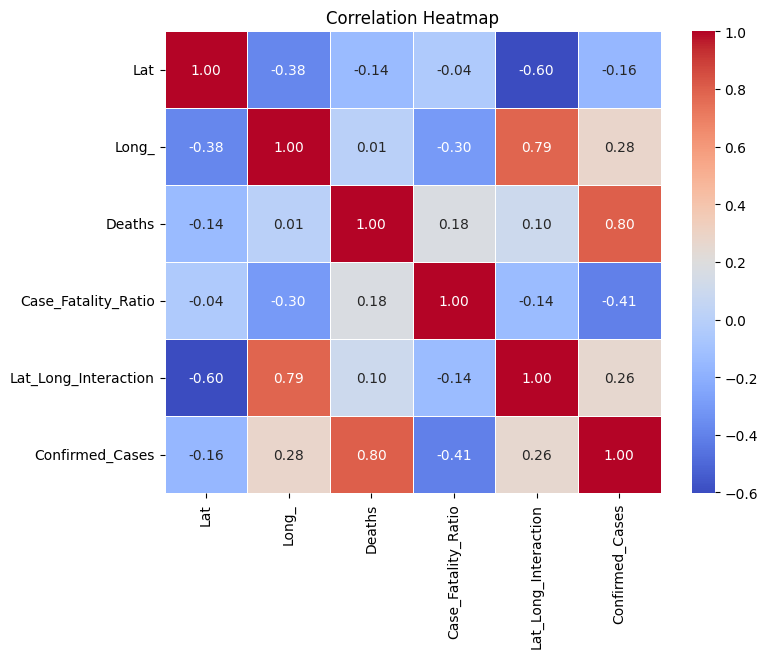

In [ ]:
correlation = data_cleaned.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

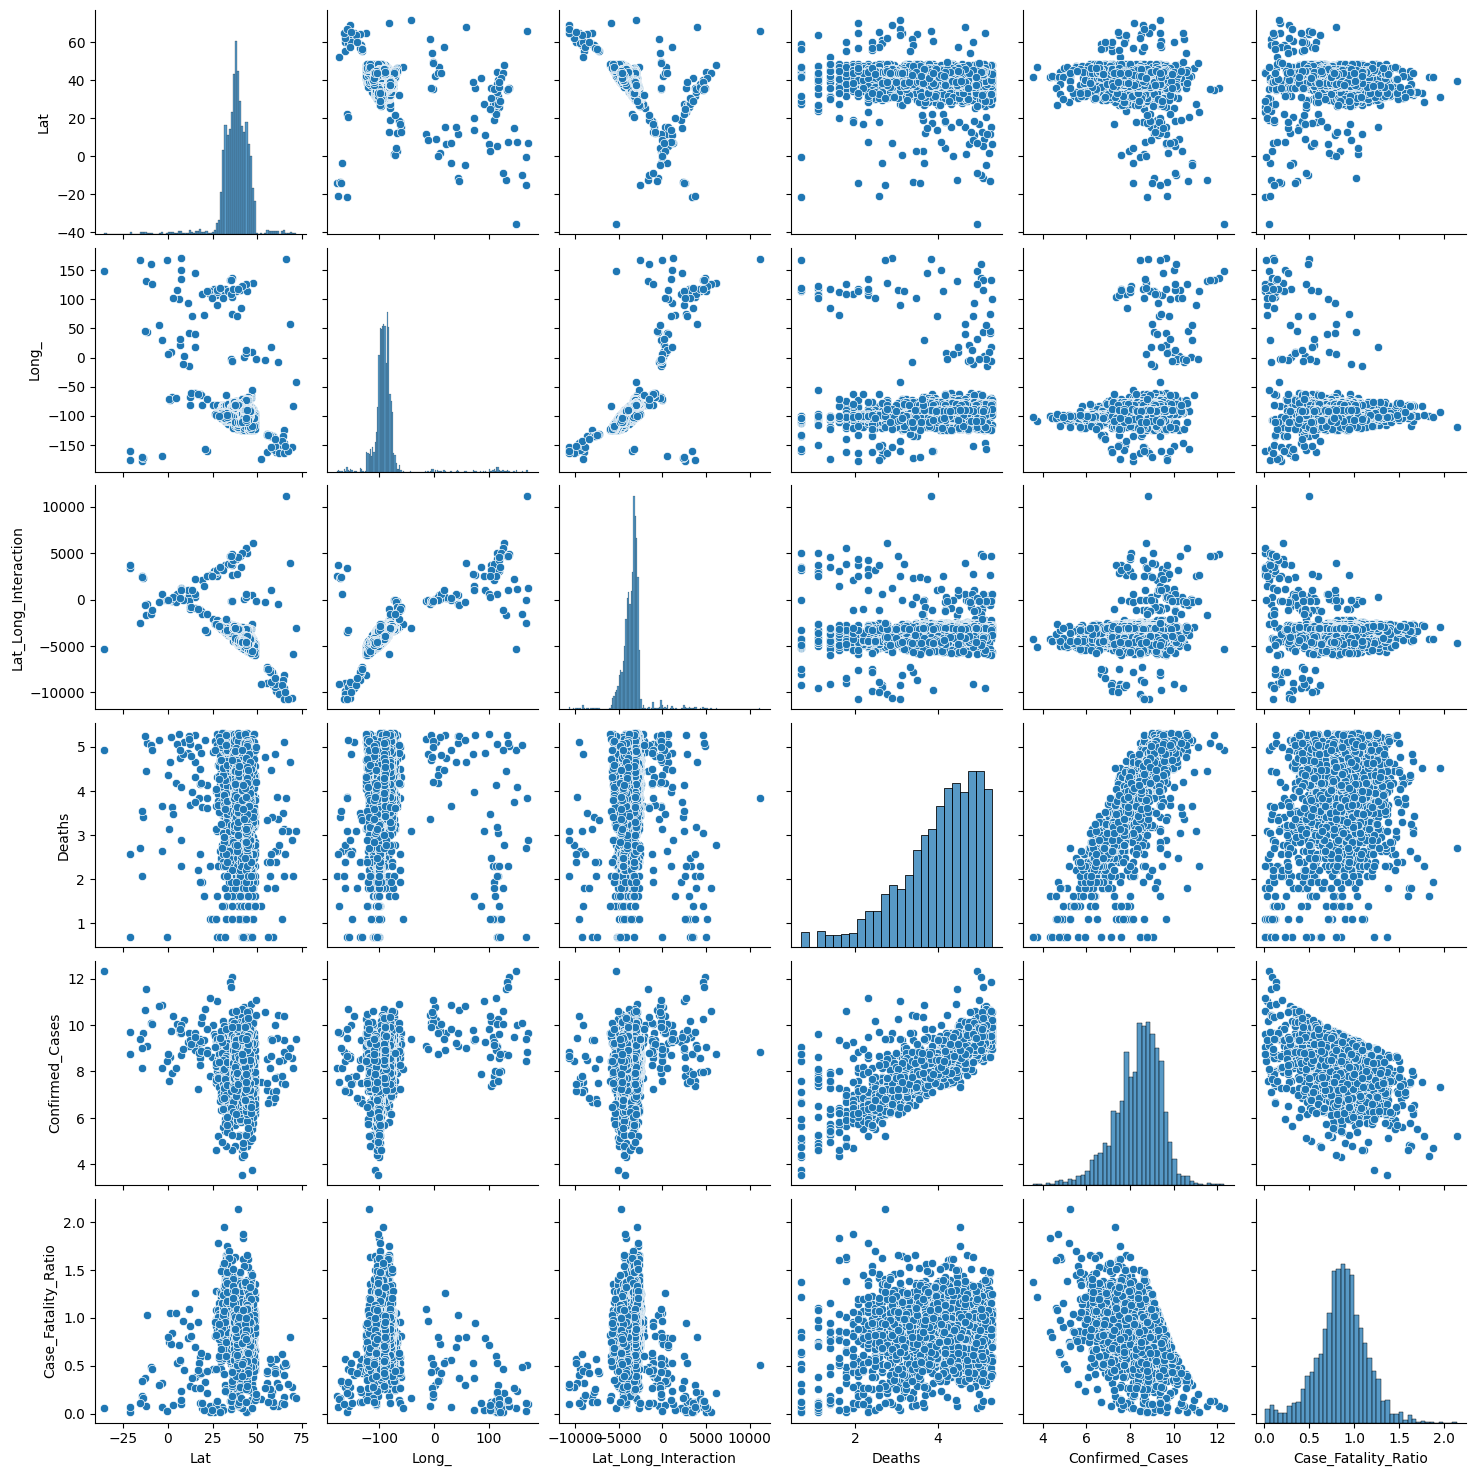

In [ ]:
# Pairplot to explore relationships between features
sns.pairplot(data_cleaned[['Lat', 'Long_','Lat_Long_Interaction', 'Deaths', 'Confirmed_Cases', 'Case_Fatality_Ratio']])
plt.show()

In [ ]:
X_cfr = data_cleaned[['Lat', 'Long_', 'Lat_Long_Interaction']]
y = data_cleaned['Case_Fatality_Ratio']

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled_Cfr = scaler.fit_transform(X_cfr)

In [ ]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X_scaled_Cfr, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10]
}

model = RandomForestRegressor()
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 10], 'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best Parameters:", grid_search.best_params_)
best_model_cfr = grid_search.best_estimator_

Best Parameters: {'max_depth': 10, 'n_estimators': 100}


In [ ]:
from sklearn.metrics import mean_squared_error

y_pred_cfr = best_model_cfr.predict(X_test)

# Evaluate using RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cfr))
print("RMSE with Optimized Parameters:", rmse)

RMSE with Optimized Parameters: 0.2235872315698995


In [ ]:
# converting log values back to normal values
y_test_cfr = np.expm1(y_test)
y_pred_cfr = np.expm1(y_pred_cfr)

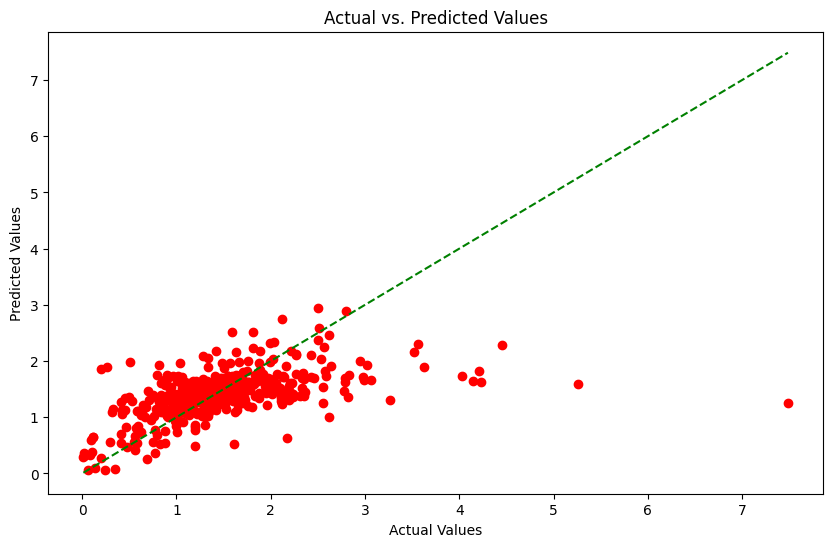

In [ ]:
# comparing both
plt.figure(figsize=(10, 6))
plt.scatter(y_test_cfr, y_pred_cfr,color='red')
plt.plot([min(y_test_cfr), max(y_test_cfr)], [min(y_test_cfr), max(y_test_cfr)], color='green', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()

In [ ]:
X_deaths = data_cleaned[['Lat', 'Long_', 'Lat_Long_Interaction','Case_Fatality_Ratio']]
y = data_cleaned['Deaths']

In [ ]:
X_scaled_deaths = scaler.fit_transform(X_deaths)

In [ ]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X_scaled_deaths, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10]
}

model = RandomForestRegressor()
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 10], 'n_estimators': [100, 200]},
             scoring='neg_mean_squared_error')

In [ ]:
print("Best Parameters:", grid_search.best_params_)
best_model_deaths = grid_search.best_estimator_

Best Parameters: {'max_depth': 10, 'n_estimators': 200}


In [ ]:
from sklearn.metrics import mean_squared_error

y_pred_deaths = best_model_deaths.predict(X_test)

# Evaluate using RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred_deaths))
print("RMSE with Optimized Parameters:", rmse)

RMSE with Optimized Parameters: 0.8191121399947761


In [ ]:
# converting log values back to mornal values
y_test_deaths = np.expm1(y_test)
y_pred_deaths = np.expm1(y_pred_deaths)

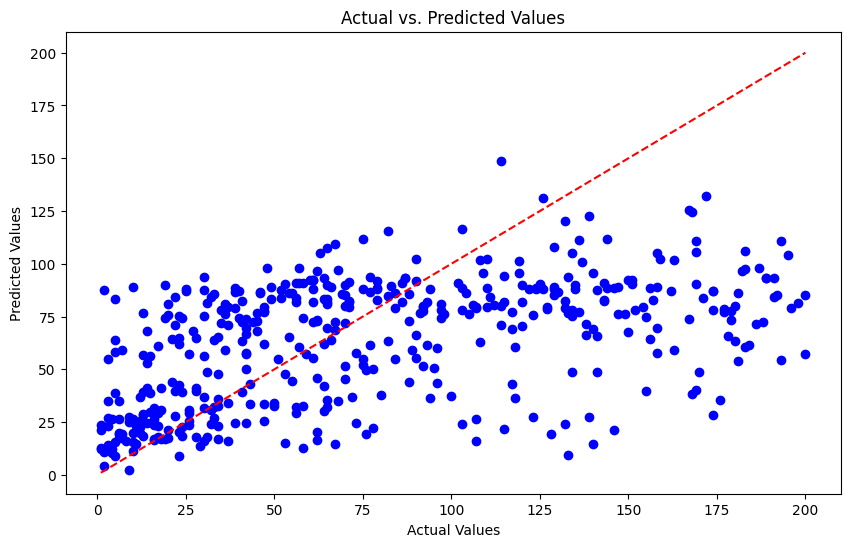

In [ ]:
# comparing both
plt.figure(figsize=(10, 6))
plt.scatter(y_test_deaths, y_pred_deaths,color='blue')
plt.plot([min(y_test_deaths), max(y_test_deaths)], [min(y_test_deaths), max(y_test_deaths)], color='red', linestyle='--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs. Predicted Values")
plt.show()

In [ ]:
test_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Hackathon /Predictioneer Hackathon /test_points.xlsx - Sheet1.csv')

In [ ]:
test_data.head()

,Lat,Long_
0,41.1533,20.1683
1,-71.9499,23.3470
2,-35.4735,149.0124
3,-34.9285,138.6007
4,47.5162,14.5501


In [ ]:
test_data.shape

(1004, 2)

In [ ]:
test_data.isnull().sum()

,0
Lat,23
Long_,23


In [ ]:
test_data = test_data.dropna(subset=['Lat', 'Long_'])

In [ ]:
test_data.isnull().sum()

,0
Lat,0
Long_,0


In [ ]:
test_data['Lat_Long_Interaction'] = test_data['Lat'] * test_data['Long_']

<ipython-input-183-2e5f2fa46652>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Lat_Long_Interaction'] = test_data['Lat'] * test_data['Long_']


In [ ]:
test_data.head()

,Lat,Long_,Lat_Long_Interaction
0,41.1533,20.1683,829.992100
1,-71.9499,23.3470,-1679.814315
2,-35.4735,149.0124,-5285.991371
3,-34.9285,138.6007,-4841.114550
4,47.5162,14.5501,691.365462


In [ ]:
cfr_test = test_data[['Lat', 'Long_', 'Lat_Long_Interaction']]
cfr_test.scaled = scaler.fit_transform(cfr_test)
y_test_cfr = best_model_cfr.predict(cfr_test.scaled)
# converting to normal value
y_test_cfr = np.expm1(y_test_cfr)

<ipython-input-185-6a3c766f974b>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  cfr_test.scaled = scaler.fit_transform(cfr_test)


In [ ]:
test_data['Case_Fatality_Ratio'] = y_test_cfr

<ipython-input-186-82c3275e4c46>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Case_Fatality_Ratio'] = y_test_cfr


In [ ]:
# now for deaths
death_test = test_data[['Lat', 'Long_', 'Lat_Long_Interaction','Case_Fatality_Ratio']]
death_test.scaled = scaler.fit_transform(death_test)
y_test_deaths = best_model_deaths.predict(death_test.scaled)
# converting back to normal value
y_test_deaths = np.expm1(y_test_deaths)

<ipython-input-187-7324a1ae5829>:3: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  death_test.scaled = scaler.fit_transform(death_test)


In [ ]:
test_data['Deaths'] = y_test_deaths

<ipython-input-188-41a6ccf8b7ec>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Deaths'] = y_test_deaths


In [ ]:
test_data.head()

,Lat,Long_,Lat_Long_Interaction,Case_Fatality_Ratio,Deaths
0,41.1533,20.1683,829.992100,0.527196,102.747297
1,-71.9499,23.3470,-1679.814315,0.878625,103.987436
2,-35.4735,149.0124,-5285.991371,0.491104,41.126896
3,-34.9285,138.6007,-4841.114550,0.692490,44.414565
4,47.5162,14.5501,691.365462,0.512087,56.592801


In [ ]:
test_data = test_data.drop(['Lat', 'Long_', 'Lat_Long_Interaction'], axis=1)

In [ ]:
test_data['Confirmed_Cases'] = (test_data['Deaths'] / test_data['Case_Fatality_Ratio'])*100

In [ ]:
test_data.head()

,Case_Fatality_Ratio,Deaths,Confirmed_Cases
0,0.527196,102.747297,19489.393535
1,0.878625,103.987436,11835.251192
2,0.491104,41.126896,8374.369295
3,0.692490,44.414565,6413.748322
4,0.512087,56.592801,11051.403840


In [ ]:
test_data.to_csv('predicted_data.csv', index=False)